# Import Required Libraries
Import necessary libraries such as pandas, numpy, matplotlib, seaborn, and any other required libraries.

In [1]:
# Import Required Libraries

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns  # For statistical data visualization

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Display plots inline within the Jupyter notebook
%matplotlib inline

# Load Data
Load the datasets ScoringNFL.csv, Umbrella.csv, Fortune500Sector.csv, EJB.csv, and Employee-Attritionv1.csv from the data folder.

In [2]:
# Load Data

# Load the ScoringNFL dataset
scoring_nfl_df = pd.read_csv('data/ScoringNFL.csv')

# Load the Umbrella dataset
umbrella_df = pd.read_csv('data/Umbrella.csv')

# Load the Fortune500Sector dataset
fortune500sector_df = pd.read_csv('data/Fortune500Sector.csv')

# Load the EJB dataset
ejb_df = pd.read_csv('data/EJB.csv')

# Load the Employee-Attrition dataset
employee_attrition_df = pd.read_csv('data/Employee-Attritionv1.csv')


In [3]:

# Display the first few rows of each dataset to verify loading
print("ScoringNFL Dataset:")
scoring_nfl_df.head(3)


ScoringNFL Dataset:


,Team,Season,Points Scored
0,Baltimore Ravens,2010,357
1,San Francisco 49ers,2010,305
2,Tampa Bay Buccaneers,2010,341


In [4]:

# Display the first few rows of each dataset to verify loading
print("Umbrella Dataset:")
umbrella_df.head(3)

Umbrella Dataset:


,Year,Quarter,Sales (Thousands $)
0,1,I,125
1,1,II,153
2,1,III,106


In [5]:
print("Fortune500Sector Dataset:")
fortune500sector_df.head(3)

Fortune500Sector Dataset:


,Company,Sector,Profits ($ millions),Market Capitalization ($ millions)
0,Alliant Techsystems,Industrials,313.2,1891.9
1,Amazon.com,Consumer,631,81458.6
2,AmerisourceBergen,Healthcare,706.6,10087.6


In [6]:
print("EJB Dataset:")
ejb_df.head(3)

EJB Dataset:


,Order ID,Flavor,Category,$ Sales,Date Ordered,Date Delivered,Distribution Center,New Customer?,Service Satisfaction Rating,Product Satisfaction Rating,Unnamed: 10
0,92145,Beet,Juices,605.97,1/1/2018,1/3/2018,ID,Yes,3.0,NaN,NaN
1,92145,Apple,Juices,1549.00,1/1/2018,1/3/2018,ID,Yes,5.0,4.0,NaN
2,92145,Apple,Juices,1986.28,1/1/2018,1/3/2018,ID,Yes,5.0,4.0,NaN


In [7]:
print("Employee-Attrition Dataset:")
employee_attrition_df.head(3)

Employee-Attrition Dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


# 1 a. Distribution of Scoring Over 10 Seasons
Construct a single chart to compare the distribution of scoring across the league over 10 seasons using the ScoringNFL.csv data.

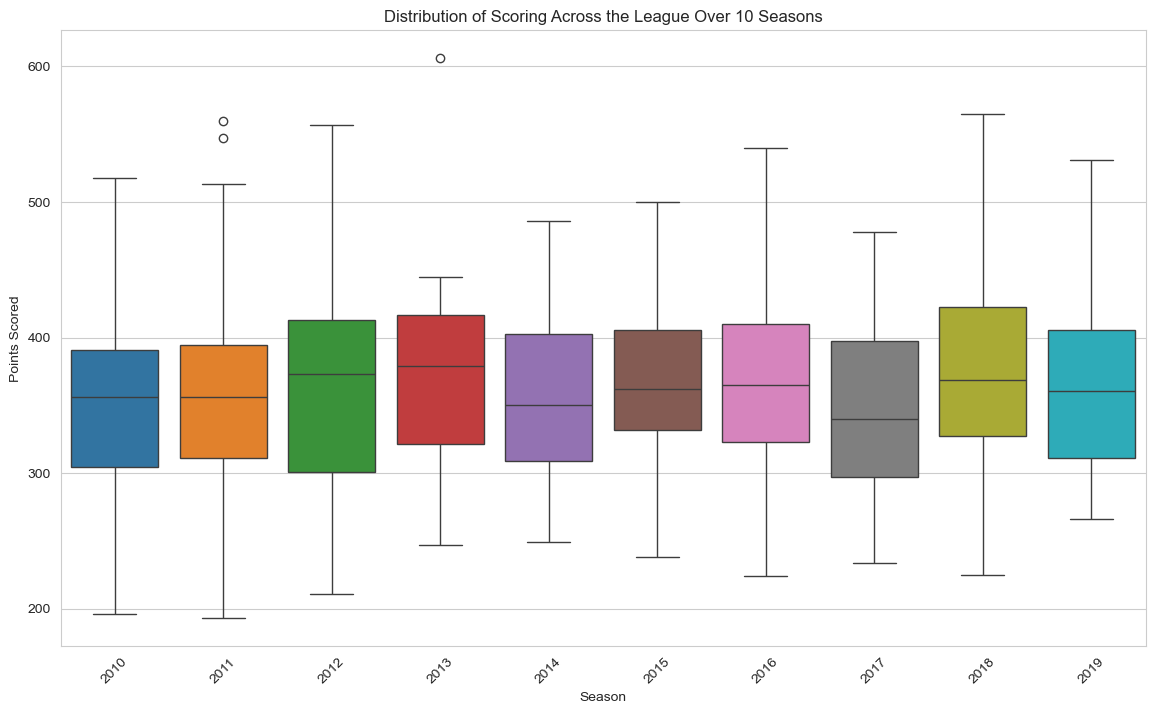

In [8]:
# Distribution of Scoring Over 10 Seasons

# Pivot the data to have seasons as columns and teams as rows
scoring_pivot = scoring_nfl_df.pivot(index='Team', columns='Season', values='Points Scored')

# Plot the distribution of scoring across the league over 10 seasons
plt.figure(figsize=(14, 8))
sns.boxplot(data=scoring_pivot)
plt.title('Distribution of Scoring Across the League Over 10 Seasons')
plt.xlabel('Season')
plt.ylabel('Points Scored')
plt.xticks(rotation=45)
plt.show()

In [9]:
# Pivot the data to have seasons as columns and teams as rows
scoring_pivot = scoring_nfl_df.pivot(index='Team', columns='Season', values='Points Scored')

# Function to find outliers for each season
def find_outliers(df):
    outliers = {}
    for season in df.columns:
        Q1 = df[season].quantile(0.25)
        Q3 = df[season].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        season_outliers = df[(df[season] < lower_bound) | (df[season] > upper_bound)][season]
        outliers[season] = season_outliers
    return outliers

# Find outliers
outliers = find_outliers(scoring_pivot)

# Print outliers
for season, outlier_values in outliers.items():
    print(f"Season {season} outliers:")
    print(outlier_values)
    print()

Season 2010 outliers:
Series([], Name: 2010, dtype: int64)

Season 2011 outliers:
Team
Green Bay Packers     560
New Orleans Saints    547
Name: 2011, dtype: int64

Season 2012 outliers:
Series([], Name: 2012, dtype: int64)

Season 2013 outliers:
Team
Denver Broncos    606
Name: 2013, dtype: int64

Season 2014 outliers:
Series([], Name: 2014, dtype: int64)

Season 2015 outliers:
Series([], Name: 2015, dtype: int64)

Season 2016 outliers:
Series([], Name: 2016, dtype: int64)

Season 2017 outliers:
Series([], Name: 2017, dtype: int64)

Season 2018 outliers:
Series([], Name: 2018, dtype: int64)

Season 2019 outliers:
Series([], Name: 2019, dtype: int64)



# Temporal Patterns in Scoring for Individual Teams
Unstack the data and use sparklines to show how scoring for each team has changed over 10 seasons. Identify teams with strong upward and downward trends.

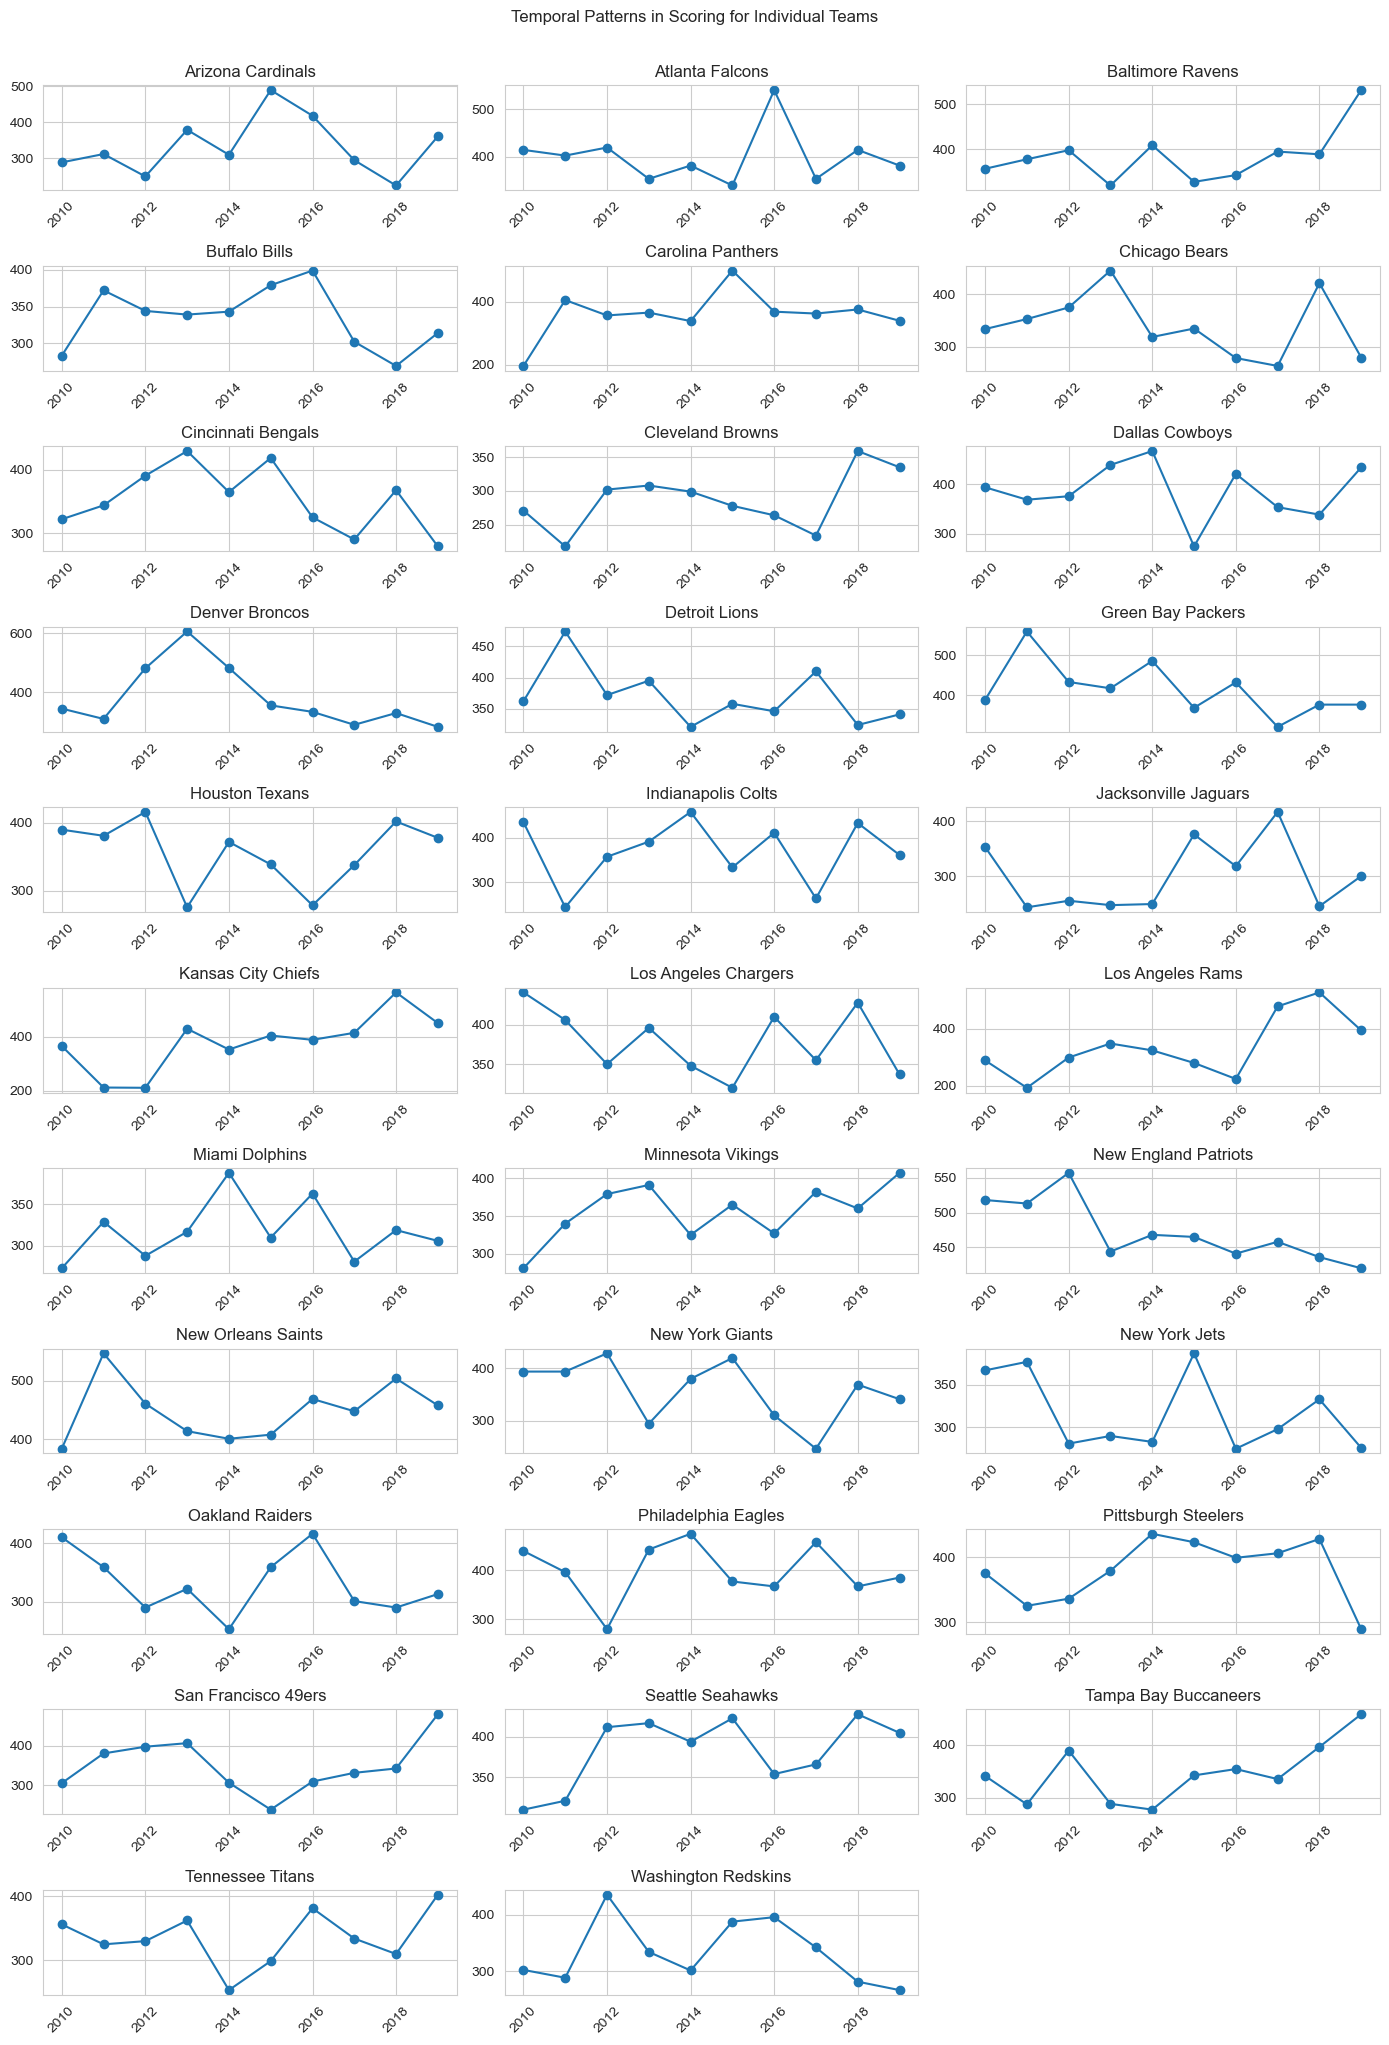

Team with strong upward trend: Kansas City Chiefs
Team with strong downward trend: Denver Broncos


In [10]:
# Temporal Patterns in Scoring for Individual Teams

# Unstack the data to have seasons as columns and teams as rows
scoring_unstacked = scoring_nfl_df.pivot(index='Team', columns='Season', values='Points Scored')

# Plot sparklines for each team to show how scoring has changed over 10 seasons
plt.figure(figsize=(14, 20))
for i, team in enumerate(scoring_unstacked.index):
    plt.subplot(len(scoring_unstacked.index) // 3 + 1, 3, i + 1)
    plt.plot(scoring_unstacked.columns, scoring_unstacked.loc[team], marker='o')
    plt.title(team)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.suptitle('Temporal Patterns in Scoring for Individual Teams', y=1.02)
plt.show()

# Calculate the trend for each team
scoring_trends = scoring_unstacked.apply(lambda x: np.polyfit(scoring_unstacked.columns, x, 1)[0], axis=1)

# Identify teams with strong upward and downward trends
strong_upward_trend_team = scoring_trends.idxmax()
strong_downward_trend_team = scoring_trends.idxmin()

print(f"Team with strong upward trend: {strong_upward_trend_team}")
print(f"Team with strong downward trend: {strong_downward_trend_team}")

# Line Chart for Sales Time Series Data
Create a line chart for the sales time series data from Umbrella.csv.

In [ ]:
# Line Chart for Sales Time Series Data

# Create a line chart for the sales time series data
plt.figure(figsize=(14, 8))
plt.plot(umbrella_df['Quarter'], umbrella_df['Sales (Thousands $)'], marker='o', linestyle='-', color='b', label='Sales')
plt.title('Sales Time Series Data')
plt.xlabel('Quarter')
plt.ylabel('Sales (Thousands $)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Add a four-period moving average to the chart to smooth the data
umbrella_df['4-Period MA'] = umbrella_df['Sales (Thousands $)'].rolling(window=4).mean()

plt.figure(figsize=(14, 8))
plt.plot(umbrella_df['Quarter'], umbrella_df['Sales (Thousands $)'], marker='o', linestyle='-', color='b', label='Sales')
plt.plot(umbrella_df['Quarter'], umbrella_df['4-Period MA'], marker='o', linestyle='-', color='r', label='4-Period MA')
plt.title('Sales Time Series Data with 4-Period Moving Average')
plt.xlabel('Quarter')
plt.ylabel('Sales (Thousands $)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Plot the data as a collection of five data series (one for each year)
umbrella_df['Year'] = umbrella_df['Year'].astype(str)
plt.figure(figsize=(14, 8))
sns.lineplot(data=umbrella_df, x='Quarter', y='Sales (Thousands $)', hue='Year', marker='o')
plt.title('Sales Time Series Data by Year')
plt.xlabel('Quarter')
plt.ylabel('Sales (Thousands $)')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.show()

# Four-Period Moving Average
Add a four-period moving average to the sales time series chart to smooth the data.

In [ ]:
# Add a four-period moving average to the sales time series chart to smooth the data

# Calculate the four-period moving average
umbrella_df['4-Period MA'] = umbrella_df['Sales (Thousands $)'].rolling(window=4).mean()

# Plot the sales time series data with the four-period moving average
plt.figure(figsize=(14, 8))
plt.plot(umbrella_df['Quarter'], umbrella_df['Sales (Thousands $)'], marker='o', linestyle='-', color='b', label='Sales')
plt.plot(umbrella_df['Quarter'], umbrella_df['4-Period MA'], marker='o', linestyle='-', color='r', label='4-Period MA')
plt.title('Sales Time Series Data with 4-Period Moving Average')
plt.xlabel('Quarter')
plt.ylabel('Sales (Thousands $)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Seasonality Analysis
Plot the data as a collection of five data series (one for each year) to investigate seasonality in the Umbrella.csv data.

In [ ]:
# Seasonality Analysis

# Plot the data as a collection of five data series (one for each year)
umbrella_df['Year'] = umbrella_df['Year'].astype(str)
plt.figure(figsize=(14, 8))
sns.lineplot(data=umbrella_df, x='Quarter', y='Sales (Thousands $)', hue='Year', marker='o')
plt.title('Sales Time Series Data by Year')
plt.xlabel('Quarter')
plt.ylabel('Sales (Thousands $)')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.show()

# Scatter Chart for Market Capitalization and Profit
Prepare a scatter chart to show the relationship between Market Capitalization and Profit using Fortune500Sector.csv data.

In [ ]:
# Scatter Chart for Market Capitalization and Profit

# Prepare a scatter chart to show the relationship between Market Capitalization and Profit
plt.figure(figsize=(14, 8))

# Scatter plot with different colors for each industry sector
sns.scatterplot(data=fortune500sector_df, x='Profits ($ millions)', y='Market Capitalization ($ millions)', hue='Sector', palette='tab10', s=100, alpha=0.7)

# Emphasize the healthcare sector by formatting all other sectors with data points in gray with no fill
healthcare_df = fortune500sector_df[fortune500sector_df['Sector'] == 'Healthcare']
non_healthcare_df = fortune500sector_df[fortune500sector_df['Sector'] != 'Healthcare']

plt.scatter(non_healthcare_df['Profits ($ millions)'], non_healthcare_df['Market Capitalization ($ millions)'], color='gray', alpha=0.5, label='Other Sectors')
plt.scatter(healthcare_df['Profits ($ millions)'], healthcare_df['Market Capitalization ($ millions)'], color='red', edgecolor='black', s=100, label='Healthcare Sector')

# Create a trendline based only on the observations in the healthcare sector
z = np.polyfit(healthcare_df['Profits ($ millions)'], healthcare_df['Market Capitalization ($ millions)'], 1)
p = np.poly1d(z)
plt.plot(healthcare_df['Profits ($ millions)'], p(healthcare_df['Profits ($ millions)']), "r--")

# Add labels and title
plt.title('Market Capitalization vs. Profit by Sector')
plt.xlabel('Profits ($ millions)')
plt.ylabel('Market Capitalization ($ millions)')
plt.legend()
plt.show()

# The trendline indicates the relationship between Market Capitalization and Profit within the healthcare sector.

# Emphasize Healthcare Sector
Format all other sectors with gray data points and create a trendline based on the healthcare sector observations.

In [ ]:
# Emphasize Healthcare Sector

# Prepare a scatter chart to show the relationship between Market Capitalization and Profit
plt.figure(figsize=(14, 8))

# Scatter plot with different colors for each industry sector
sns.scatterplot(data=fortune500sector_df, x='Profits ($ millions)', y='Market Capitalization ($ millions)', hue='Sector', palette='tab10', s=100, alpha=0.7)

# Emphasize the healthcare sector by formatting all other sectors with data points in gray with no fill
healthcare_df = fortune500sector_df[fortune500sector_df['Sector'] == 'Healthcare']
non_healthcare_df = fortune500sector_df[fortune500sector_df['Sector'] != 'Healthcare']

plt.scatter(non_healthcare_df['Profits ($ millions)'], non_healthcare_df['Market Capitalization ($ millions)'], color='gray', alpha=0.5, label='Other Sectors')
plt.scatter(healthcare_df['Profits ($ millions)'], healthcare_df['Market Capitalization ($ millions)'], color='red', edgecolor='black', s=100, label='Healthcare Sector')

# Create a trendline based only on the observations in the healthcare sector
z = np.polyfit(healthcare_df['Profits ($ millions)'], healthcare_df['Market Capitalization ($ millions)'], 1)
p = np.poly1d(z)
plt.plot(healthcare_df['Profits ($ millions)'], p(healthcare_df['Profits ($ millions)']), "r--")

# Add labels and title
plt.title('Market Capitalization vs. Profit by Sector')
plt.xlabel('Profits ($ millions)')
plt.ylabel('Market Capitalization ($ millions)')
plt.legend()
plt.show()

# The trendline indicates the relationship between Market Capitalization and Profit within the healthcare sector.

# Relative Frequency Distribution of Category
Construct the relative frequency distribution of records over the values of the Category variable in EJB.csv.

In [ ]:
# Relative Frequency Distribution of Category

# Calculate the relative frequency distribution of records over the values of the Category variable
category_relative_freq = ejb_df['Category'].value_counts(normalize=True)

# Display the relative frequency distribution
print("Relative Frequency Distribution of Category:")
print(category_relative_freq)

# Plot the relative frequency distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=category_relative_freq.index, y=category_relative_freq.values, palette='viridis')
plt.title('Relative Frequency Distribution of Category')
plt.xlabel('Category')
plt.ylabel('Relative Frequency')
plt.xticks(rotation=45)
plt.show()

# Relative Frequency Distribution of New Customer
Construct the relative frequency distribution of records over the values of the New Customer variable in EJB.csv and relabel values.

In [ ]:
# Relative Frequency Distribution of New Customer

# Calculate the relative frequency distribution of records over the values of the New Customer variable
new_customer_relative_freq = ejb_df['New Customer?'].value_counts(normalize=True)

# Relabel the values: "No" to "Existing" and "Yes" to "New"
ejb_df['New Customer?'] = ejb_df['New Customer?'].replace({'No': 'Existing', 'Yes': 'New'})

# Display the relative frequency distribution
print("Relative Frequency Distribution of New Customer:")
print(new_customer_relative_freq)

# Plot the relative frequency distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=new_customer_relative_freq.index, y=new_customer_relative_freq.values, palette='viridis')
plt.title('Relative Frequency Distribution of New Customer')
plt.xlabel('New Customer')
plt.ylabel('Relative Frequency')
plt.xticks(rotation=45)
plt.show()

# Analysis of Missing Data in Product Satisfaction Rating
Construct the relative frequency distribution of records over the values of the Product Satisfaction Rating variable in EJB.csv and analyze missing data.

In [ ]:
# Analysis of Missing Data in Product Satisfaction Rating

# Construct the relative frequency distribution of records over the values of the Product Satisfaction Rating variable
product_satisfaction_freq = ejb_df['Product Satisfaction Rating'].value_counts(normalize=True, dropna=False)

# Display the relative frequency distribution
print("Relative Frequency Distribution of Product Satisfaction Rating:")
print(product_satisfaction_freq)

# Plot the relative frequency distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=product_satisfaction_freq.index, y=product_satisfaction_freq.values, palette='viridis')
plt.title('Relative Frequency Distribution of Product Satisfaction Rating')
plt.xlabel('Product Satisfaction Rating')
plt.ylabel('Relative Frequency')
plt.xticks(rotation=45)
plt.show()

# Calculate the percentage of records missing a value for Product Satisfaction Rating
missing_percentage = product_satisfaction_freq.loc[np.nan] * 100
print(f"Percentage of records missing Product Satisfaction Rating: {missing_percentage:.2f}%")

# Considering only records that report values of Product Satisfaction Rating
reported_satisfaction_df = ejb_df.dropna(subset=['Product Satisfaction Rating'])

# Construct the relative frequency distribution of records over the different flavors
flavor_freq_reported = reported_satisfaction_df['Flavor'].value_counts(normalize=True)

# Display the relative frequency distribution for reported satisfaction ratings
print("Relative Frequency Distribution of Flavors (Reported Satisfaction Ratings):")
print(flavor_freq_reported)

# Plot the relative frequency distribution for reported satisfaction ratings
plt.figure(figsize=(10, 6))
sns.barplot(x=flavor_freq_reported.index, y=flavor_freq_reported.values, palette='viridis')
plt.title('Relative Frequency Distribution of Flavors (Reported Satisfaction Ratings)')
plt.xlabel('Flavor')
plt.ylabel('Relative Frequency')
plt.xticks(rotation=45)
plt.show()

# Considering records that are missing values of Product Satisfaction Rating
missing_satisfaction_df = ejb_df[ejb_df['Product Satisfaction Rating'].isna()]

# Construct the relative frequency distribution of records over the different flavors
flavor_freq_missing = missing_satisfaction_df['Flavor'].value_counts(normalize=True)

# Display the relative frequency distribution for missing satisfaction ratings
print("Relative Frequency Distribution of Flavors (Missing Satisfaction Ratings):")
print(flavor_freq_missing)

# Plot the relative frequency distribution for missing satisfaction ratings
plt.figure(figsize=(10, 6))
sns.barplot(x=flavor_freq_missing.index, y=flavor_freq_missing.values, palette='viridis')
plt.title('Relative Frequency Distribution of Flavors (Missing Satisfaction Ratings)')
plt.xlabel('Flavor')
plt.ylabel('Relative Frequency')
plt.xticks(rotation=45)
plt.show()

# Compare the distributions in part (b) and part (c)
comparison_df = pd.DataFrame({
    'Reported': flavor_freq_reported,
    'Missing': flavor_freq_missing
}).fillna(0)

# Plot the comparison of distributions
comparison_df.plot(kind='bar', figsize=(14, 8), colormap='viridis')
plt.title('Comparison of Flavor Distributions (Reported vs. Missing Satisfaction Ratings)')
plt.xlabel('Flavor')
plt.ylabel('Relative Frequency')
plt.xticks(rotation=45)
plt.legend(title='Satisfaction Rating')
plt.show()

# Data Cleaning
Validate that the Employee-Attritionv1.csv data is clean and include the code for validation.

In [ ]:
# Data Cleaning

# Display basic information about the dataset
print("Basic Information about Employee-Attrition Dataset:")
print(employee_attrition_df.info(), "\n")

# Check for missing values in the dataset
missing_values = employee_attrition_df.isnull().sum()
print("Missing Values in Employee-Attrition Dataset:")
print(missing_values[missing_values > 0], "\n")

# Check for duplicate rows in the dataset
duplicate_rows = employee_attrition_df.duplicated().sum()
print(f"Number of Duplicate Rows in Employee-Attrition Dataset: {duplicate_rows}\n")

# Display summary statistics for numerical columns
print("Summary Statistics for Numerical Columns:")
print(employee_attrition_df.describe(), "\n")

# Display summary statistics for categorical columns
print("Summary Statistics for Categorical Columns:")
print(employee_attrition_df.describe(include=['object']), "\n")

# Check for unique values in each categorical column
print("Unique Values in Categorical Columns:")
for col in employee_attrition_df.select_dtypes(include=['object']).columns:
    print(f"{col}: {employee_attrition_df[col].nunique()} unique values")

# Validate that the data is clean
# If there are no missing values, no duplicate rows, and the summary statistics look reasonable, the data is considered clean.

# Exploratory Data Analysis (EDA)
Explore the Employee-Attritionv1.csv data for further analysis and include code for EDA.

In [ ]:
# Exploratory Data Analysis (EDA)

# Display the first few rows of the Employee-Attrition dataset
print("First few rows of Employee-Attrition Dataset:")
print(employee_attrition_df.head(), "\n")

# Display the basic information about the dataset
print("Basic Information about Employee-Attrition Dataset:")
print(employee_attrition_df.info(), "\n")

# Check for missing values in the dataset
missing_values = employee_attrition_df.isnull().sum()
print("Missing Values in Employee-Attrition Dataset:")
print(missing_values[missing_values > 0], "\n")

# Check for duplicate rows in the dataset
duplicate_rows = employee_attrition_df.duplicated().sum()
print(f"Number of Duplicate Rows in Employee-Attrition Dataset: {duplicate_rows}\n")

# Display summary statistics for numerical columns
print("Summary Statistics for Numerical Columns:")
print(employee_attrition_df.describe(), "\n")

# Display summary statistics for categorical columns
print("Summary Statistics for Categorical Columns:")
print(employee_attrition_df.describe(include=['object']), "\n")

# Check for unique values in each categorical column
print("Unique Values in Categorical Columns:")
for col in employee_attrition_df.select_dtypes(include=['object']).columns:
    print(f"{col}: {employee_attrition_df[col].nunique()} unique values")

# Plot the distribution of numerical features
numerical_cols = employee_attrition_df.select_dtypes(include=['int64', 'float64']).columns
employee_attrition_df[numerical_cols].hist(bins=15, figsize=(15, 10), layout=(5, 4))
plt.suptitle('Distribution of Numerical Features')
plt.show()

# Plot the distribution of categorical features
categorical_cols = employee_attrition_df.select_dtypes(include=['object']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(y=col, data=employee_attrition_df, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

# Plot the correlation matrix
plt.figure(figsize=(15, 10))
correlation_matrix = employee_attrition_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Pairplot of numerical features
sns.pairplot(employee_attrition_df[numerical_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Boxplot of numerical features grouped by Attrition
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(x='Attrition', y=col, data=employee_attrition_df, palette='viridis')
    plt.title(f'{col} by Attrition')
    plt.tight_layout()

plt.show()

# Useful Visualizations
Identify and create the most useful visualizations for the Employee-Attritionv1.csv dataset.

In [ ]:
# Useful Visualizations

# Plot the distribution of numerical features
numerical_cols = employee_attrition_df.select_dtypes(include=['int64', 'float64']).columns
employee_attrition_df[numerical_cols].hist(bins=15, figsize=(15, 10), layout=(5, 4))
plt.suptitle('Distribution of Numerical Features')
plt.show()

# Plot the distribution of categorical features
categorical_cols = employee_attrition_df.select_dtypes(include=['object']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(y=col, data=employee_attrition_df, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

# Plot the correlation matrix
plt.figure(figsize=(15, 10))
correlation_matrix = employee_attrition_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Pairplot of numerical features
sns.pairplot(employee_attrition_df[numerical_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Boxplot of numerical features grouped by Attrition
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(x='Attrition', y=col, data=employee_attrition_df, palette='viridis')
    plt.title(f'{col} by Attrition')
    plt.tight_layout()

plt.show()

# Machine Learning Applications
Discuss how machine learning could be useful in exploring the Employee-Attritionv1.csv dataset.

In [ ]:
# Machine Learning Applications

# Import necessary libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Prepare the data for machine learning
# Drop columns that are not useful for prediction
employee_attrition_ml_df = employee_attrition_df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'])

# Convert categorical variables to dummy variables
employee_attrition_ml_df = pd.get_dummies(employee_attrition_ml_df, drop_first=True)

# Define the feature matrix (X) and the target vector (y)
X = employee_attrition_ml_df.drop(columns=['Attrition_Yes'])
y = employee_attrition_ml_df['Attrition_Yes']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the feature matrix
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
feature_importances = pd.Series(rf_classifier.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh', figsize=(10, 6), colormap='viridis')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Data Fluency Discussion
Discuss the value of data fluency as a new manager of a Data Science function in a Financial Services company.

In [ ]:
# Data Fluency Discussion

# Data fluency is the ability to understand, analyze, and communicate data effectively. As a new manager of a Data Science function in a Financial Services company, data fluency is crucial for several reasons:

# 1. **Informed Decision Making**: Data fluency enables you to make data-driven decisions, which are more likely to be accurate and effective. By understanding the data, you can identify trends, patterns, and insights that can inform strategic decisions.

# 2. **Effective Communication**: Being data fluent allows you to communicate complex data insights to non-technical stakeholders in a clear and concise manner. This is essential for gaining buy-in and support for data-driven initiatives.

# 3. **Identifying Opportunities**: Data fluency helps you identify new opportunities for growth and improvement. By analyzing data, you can uncover areas where the company can optimize processes, reduce costs, and increase revenue.

# 4. **Risk Management**: In the Financial Services industry, managing risk is critical. Data fluency allows you to analyze risk factors and develop strategies to mitigate them. This can help protect the company from potential financial losses.

# 5. **Enhancing Customer Experience**: Understanding customer data can help you tailor products and services to meet their needs better. Data fluency enables you to analyze customer behavior and preferences, leading to improved customer satisfaction and loyalty.

# 6. **Staying Competitive**: In today's data-driven world, companies that leverage data effectively have a competitive advantage. Data fluency ensures that you can keep up with industry trends and stay ahead of competitors.

# 7. **Building a Data-Driven Culture**: As a manager, you play a key role in fostering a data-driven culture within your team. By being data fluent, you can lead by example and encourage your team to use data in their daily work.

# In summary, data fluency is a valuable skill for a manager in a Data Science function. It empowers you to make informed decisions, communicate effectively, identify opportunities, manage risks, enhance customer experience, stay competitive, and build a data-driven culture.